In [11]:
using DelimitedFiles
#using GR_jll
#using GR
using Plots
using ITensors
using ITensorMPS
using PyPlot

In [ ]:

id=2

file_path = "dict/$(id)_dictionary_data"

# Read data from the file
data = readdlm(file_path, '\t', Any,skipstart=1)

# Create a dictionary from the data
temp_dict = Dict(data[:, 1] .=> data[:, 2])

# Display the new dictionary
@show temp_dict

Gsqr=temp_dict["Gsqr"]
Gsqr_b=temp_dict["Gsqr_b"]
m=temp_dict["m"]
L=Int(temp_dict["L"])
f=Int(temp_dict["f"])
dummy=temp_dict["dummy"]
write_eigenstate_file=temp_dict["write_eigenstate_file"]
tmax = temp_dict["tmax"]
nstep = Int(temp_dict["nstep"])
tau=tmax/nstep
println("dt=",tau)
println(Gsqr)
Gsqr_b_str=string(Gsqr_b)

LoadError: ArgumentError: Cannot open 'dictionary_data/2_dictionary_data': not a file

# Create Gates for 1 trotter step

In [ ]:
s = siteinds("S=1/2",2*L)

mycutoff = 1E-16
maxdim=16




# Make gates (1,2),(2,3),(3,4),...
gates = ITensor[]

for j=1:2:2*L-3
    println(j)
    sind1 = s[j] #flavor1
    sind2= s[j+1] #flavor2
    sind3=s[j+2] #flavor1
    sind4=s[j+3] #flavor2
    
    #interaction term
    if Gsqr!=0
        hj = 2*Gsqr * op("S- * S+",sind1) * op("S- * S+",sind2)
        Gj = exp(-im * tau/2 * hj)
        push!(gates,Gj)
    end


    #flavor 1
    hj=-2*im * op("S+",sind1) * op("S-",sind3) +
         +2*im* op("S-",sind1) * op("S+",sind3)
    Gj = exp(-im * tau/2 * hj)
    push!(gates,Gj)

    #flavor 2
    hj=-2*im  * op("S+",sind2) * op("S-",sind4) +
         +2*im * op("S-",sind2) * op("S+",sind4) 
    Gj = exp(-im * tau/2 * hj)
    push!(gates,Gj)

    # mass term
    if m!=0
        hj = 2*m*(-1)^(j-1) * op("S- * S+",sind1) 
        Gj = exp(-im * tau/2 * hj)
        push!(gates,Gj)
        
        hj = 2*m*(-1)^(j) *op("S- * S+",sind2)
        Gj = exp(-im * tau/2 * hj)
        push!(gates,Gj)
        
        #println("Got here")
    end
    
end

hN=2*Gsqr * op("S- * S+",s[2*L-1]) * op("S- * S+",s[2*L])
GN = exp(-im * tau/2 * hN)
push!(gates,GN)

# mass term
if m!=0
    hj = 2*m*(-1)^(2*L-2) * op("S- * S+",s[2*L-1]) 
    Gj = exp(-im * tau/2 * hj)
    push!(gates,Gj)

    hj =   2*m*(-1)^(2*L-1) *op("S- * S+",s[2*L])
    Gj = exp(-im * tau/2 * hj)
    push!(gates,Gj)
end

# Include gates in reverse order too
# (N,N-1),(N-1,N-2),...
append!(gates,reverse(gates))
println("gates created")

1
3
5
7
9
11
13
15
17
19
21
23
25
27
29
gates created


# Create Wavepacket

In [ ]:
# Phase convention: exp(i * k0 * (x - 1))
# k0 is a physical momentum (e.g. 2pi/N).
# x is the 1-based lattice site index; phase is zero at x=1.
# This matches the projector convention in myphases below.
function gaussian_wavepacket(x, x0, k0, sigma)
    return exp(-0.5 * ((x - x0) / sigma)^2 + im * k0 * (x - 1))
end

# Create a two-flavor Gaussian wavepacket MPS on a staggered 1D chain.
#
# Qubit layout: qubit 2n-1 = flavor-1 at lattice site n
#               qubit 2n   = flavor-2 at lattice site n
#
# subindex_arr_f1 = [1, 3, 5, ..., 2L-1]  (flavor-1 qubit indices)
# subindex_arr_f2 = [2, 4, 6, ..., 2L]    (flavor-2 qubit indices)
#
# Both flavors share the loop variable ind (1..Nsites) as the physical
# lattice coordinate. Each term in the MPS sum has BOTH flavor-1 AND
# flavor-2 excited at the same lattice site ind.
function create_wavepacket_MPS(sites, Q,
                               x0, k0, sigma,    subindex_arr_f1,
                               x1, k1, sigma1,   subindex_arr_f2,
                               want_normalize=1)

    Nsites = length(subindex_arr_f1)
    @assert length(subindex_arr_f1) == length(subindex_arr_f2) "Flavor index arrays must have equal length"

    psi_c = MPS(sites)

    for ind in 1:Nsites
        j_f1 = subindex_arr_f1[ind]   # qubit index of flavor-1 at lattice site ind
        j_f2 = subindex_arr_f2[ind]   # qubit index of flavor-2 at lattice site ind

        amp_f1 = gaussian_wavepacket(ind, x0, k0, sigma)
        amp_f2 = gaussian_wavepacket(ind, x1, k1, sigma1)

        # Product state: both flavors excited at lattice site ind
        state = ["Dn" for k in 1:Q]
        state[j_f1] = "Up"
        state[j_f2] = "Up"

        psi_temp = MPS(sites, state)
        psi_temp[j_f1] = amp_f1 * psi_temp[j_f1]
        psi_temp[j_f2] = amp_f2 * psi_temp[j_f2]

        if ind == 1
            psi_c = psi_temp
        else
            psi_c = psi_c + psi_temp
        end
    end

    if want_normalize == 1
        normalize!(psi_c)
    end

    println("maxlinkdim(psi_wp) = ", maxlinkdim(psi_c))
    return psi_c
end

# ── Parameters ────────────────────────────────────────────────────────────
N  = L            # number of spatial lattice sites
Q  = 2 * L        # total qubits (2 flavors x N sites)

# Flavor-1: right-mover, starts in left quarter of chain
x0    = N / 4
k0    = 2*pi / N   # physical momentum = one Brillouin-zone unit
sigma = N / 8

# Flavor-2: left-mover, starts in right quarter of chain
x1     = 3 * N / 4
k1     = -2*pi / N
sigma1 = N / 8

# Qubit indices for each flavor on the staggered chain
subindex_arr_f1 = collect(1:2:2*L-1)   # [1, 3, 5, ..., 2L-1]
subindex_arr_f2 = collect(2:2:2*L)     # [2, 4, 6, ..., 2L]

println("flavor-1 qubit indices: ", subindex_arr_f1)
println("flavor-2 qubit indices: ", subindex_arr_f2)

psi_wp = create_wavepacket_MPS(s, Q,
                               x0, k0, sigma,   subindex_arr_f1,
                               x1, k1, sigma1,  subindex_arr_f2)


odd_index[1, 3, 5, 7, 9, 11, 13, 15]
even_index[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32]
 + 0.0im46735834974
0.23210923469349284im
 + 0.6240195441936914im
0.38268343236508984 + 0.9238795325112867im
5.403735035038392e-17 + 0.8824969025845955im
-0.23210923469349282 + 0.5603612623490701im
-0.22956396119803335 + 0.22956396119803338im
-0.12503349820892432 + 0.05179057070908856im


In [ ]:
# myphases: plane-wave phase for integer mode index n_mode on an N-site chain.
# Convention: exp(i * 2pi/N * n_mode * (x - 1)), zero at x=1.
# Physical momentum: k = 2pi/N * n_mode
# Matches gaussian_wavepacket with k0 = 2pi/N * n_mode.
function myphases(x, n_mode, N)
    return exp(im * 2*pi / N * n_mode * (x - 1))
end

# Build a uniform plane-wave MPS for two flavors.
# n_f1, n_f2: integer mode indices for flavor-1 and flavor-2.
# Physical momenta: k_f1 = 2pi/N * n_f1,  k_f2 = 2pi/N * n_f2.
function create_k_prod_k_MPS(sites, Q,
                              n_f1, N, subindex_arr_f1,
                              n_f2,    subindex_arr_f2,
                              want_normalize=1)

    Nsites = length(subindex_arr_f1)
    @assert length(subindex_arr_f1) == length(subindex_arr_f2)

    psi_c = MPS(sites)

    for ind in 1:Nsites
        j_f1 = subindex_arr_f1[ind]
        j_f2 = subindex_arr_f2[ind]

        p_f1 = myphases(ind, n_f1, N)
        p_f2 = myphases(ind, n_f2, N)

        state = ["Dn" for k in 1:Q]
        state[j_f1] = "Up"
        state[j_f2] = "Up"

        psi_temp = MPS(sites, state)
        psi_temp[j_f1] = p_f1 * psi_temp[j_f1]
        psi_temp[j_f2] = p_f2 * psi_temp[j_f2]

        if ind == 1
            psi_c = psi_temp
        else
            psi_c = psi_c + psi_temp
        end
    end

    if want_normalize == 1
        normalize!(psi_c)
    end

    return psi_c
end

# Projector for right-movers: n_mode = +1  =>  k_physical = +2pi/N
subindex_arr_f1 = collect(1:2:2*L-1)
subindex_arr_f2 = collect(2:2:2*L)

n_plus = 1
kp_prod_kp = create_k_prod_k_MPS(s, Q,
                                  n_plus, N, subindex_arr_f1,
                                  n_plus,    subindex_arr_f2)
normalize!(kp_prod_kp)

# Projector for left-movers: n_mode = -1  =>  k_physical = -2pi/N
n_minus = -1
km_prod_km = create_k_prod_k_MPS(s, Q,
                                  n_minus, N, subindex_arr_f1,
                                  n_minus,    subindex_arr_f2)
normalize!(km_prod_km)


1.0 + 0.0im
0.9238795325112867 + 0.3826834323650898im
0.7071067811865476 + 0.7071067811865475im
0.38268343236508984 + 0.9238795325112867im
6.123233995736766e-17 + 1.0im
 + 0.9238795325112867im
-0.7071067811865475 + 0.7071067811865476im
-0.9238795325112867 + 0.3826834323650899im
1.0 - 0.0im
0.9238795325112867 - 0.3826834323650898im
0.7071067811865476 - 0.7071067811865475im
0.38268343236508984 - 0.9238795325112867im
6.123233995736766e-17 - 1.0im
-0.3826834323650897 - 0.9238795325112867im
-0.7071067811865475 - 0.7071067811865476im
-0.9238795325112867 - 0.3826834323650899im


32-element MPS:
 ((dim=2|id=794|"S=1/2,Site,n=1"), (dim=3|id=262|"Link,l=1"))
 ((dim=2|id=323|"S=1/2,Site,n=2"), (dim=3|id=486|"Link,l=2"), (dim=3|id=262|"Link,l=1"))
 ((dim=2|id=771|"S=1/2,Site,n=3"), (dim=4|id=626|"Link,l=3"), (dim=3|id=486|"Link,l=2"))
 ((dim=2|id=694|"S=1/2,Site,n=4"), (dim=3|id=450|"Link,l=4"), (dim=4|id=626|"Link,l=3"))
 ((dim=2|id=126|"S=1/2,Site,n=5"), (dim=4|id=217|"Link,l=5"), (dim=3|id=450|"Link,l=4"))
 ((dim=2|id=385|"S=1/2,Site,n=6"), (dim=3|id=602|"Link,l=6"), (dim=4|id=217|"Link,l=5"))
 ((dim=2|id=808|"S=1/2,Site,n=7"), (dim=4|id=488|"Link,l=7"), (dim=3|id=602|"Link,l=6"))
 ((dim=2|id=868|"S=1/2,Site,n=8"), (dim=3|id=334|"Link,l=8"), (dim=4|id=488|"Link,l=7"))
 ((dim=2|id=563|"S=1/2,Site,n=9"), (dim=4|id=994|"Link,l=9"), (dim=3|id=334|"Link,l=8"))
 ((dim=2|id=859|"S=1/2,Site,n=10"), (dim=3|id=218|"Link,l=10"), (dim=4|id=994|"Link,l=9"))
 ((dim=2|id=99|"S=1/2,Site,n=11"), (dim=4|id=424|"Link,l=11"), (dim=3|id=218|"Link,l=10"))
 ((dim=2|id=611|"S=1/2,Site,

# Time evolution of operator expectation values

In [ ]:

initial_state = psi_wp
psif=initial_state

#states = [((n==1) || (n==4)) ? "Dn" : "Up" for n=1:2*L] # Up means qubit in zero state
#println(states)
#psif = MPS(ComplexF64, s, states)

normalize!(psif)



#tmax=4.0
#nstep=50.0
#tau=Float64(1.0*tmax/nstep)
mytime=collect(range(0,stop=tmax,step=tau))

Pplus=[]
Pminus=[]
mz_array=[]
nz_array=[]
x_array=[]

#expectation values at zero time
temp=inner(kp_prod_kp,initial_state)
push!(Pplus, abs(temp)^2 )

temp=inner(km_prod_km,initial_state)
push!(Pminus, abs(temp)^2 )



mz = expect(psif, "Sz"; sites=1:2:Q)-expect(psif, "Sz"; sites=2:2:Q)
push!(mz_array,mz)
#println("mz", mz)
nz = expect(psif, "Sz"; sites=1:2:Q)+expect(psif, "Sz"; sites=2:2:Q)
push!(nz_array,nz)
@show nz_array


#x_temp = inner(psif', pos_op, psif)
#push!(x_array,x_temp)
#@show x_array

# Do the time evolution by applying the gates
# for nstep steps
for step=1:nstep
    println("step=",step)
    psif = apply(gates, psif;cutoff=mycutoff)
    #println("DEBUG")
    normalize!(psif) 
    
    temp=inner(kp_prod_kp,psif) # conjugation already taken care of by inner
    push!(Pplus, abs(temp)^2 )
    
    temp=inner(km_prod_km,psif) 
    push!(Pminus, abs(temp)^2 )
    
    
    mz = expect(psif, "Sz"; sites=1:2:Q)-expect(psif, "Sz"; sites=2:2:Q)
    push!(mz_array,mz)

    nz = expect(psif, "Sz"; sites=1:2:Q)+expect(psif, "Sz"; sites=2:2:Q)
    push!(nz_array,nz)

        
    #x_temp =  inner(psif', pos_op, psif)
    #push!(x_array,x_temp)
end


Pplus=real.(Pplus)
Pminus=real.(Pminus)

Rplus=[]
Rminus=[]

for i=1:nstep+1
    push!(Rplus,(Pplus[i])/(Pplus[i]+Pminus[i]))
    push!(Rminus,(Pminus[i])/(Pplus[i]+Pminus[i]))
end    
    
#@show kproj

mz_array=real.(mz_array)
#@show mz_array

nz_array=real.(nz_array)
#@show nz_array

file_path2 = "$(id)_Rdata"
writedlm(file_path2, hcat(mytime,Rplus,Rminus), '\t')

Pminus


nz_array = Any[[-0.9999999999738811, -0.9999999826272092, -0.9999957490182978, -0.9996173388219711, -0.987328002142545, -0.8456234626315118, -0.308132359759011, 0.14069689497442878, -0.9999999999999996, -0.9999999999999996, -0.9999999999999996, -0.9999999999999996, -0.9999999999999996, -0.9999999999999996, -0.9999999999999996, -0.9999999999999996]]
step=1
step=2
step=3
step=4
step=5
step=6
7tep=
step=8
9tep=
step=10
11ep=
step=12
13ep=
step=14
15ep=
step=16
17ep=
step=18
19ep=
step=20
21ep=
step=22
23ep=
step=24
25ep=
step=26
27ep=
step=28
29ep=
step=30
31ep=
step=32
33ep=
step=34
35ep=
step=36
37ep=
step=38
39ep=
step=40
41ep=
step=42
43ep=
step=44
45ep=
step=46
47ep=
step=48
49ep=
step=50
51ep=
step=52
53ep=
step=54
55ep=
step=56
57ep=
step=58
59ep=
step=60
61ep=
step=62
63ep=
step=64
65ep=
step=66
67ep=
step=68
69ep=
step=70
71ep=
step=72
73ep=
step=74
75ep=
step=76
77ep=
step=78
79ep=
step=80
81ep=
step=82
83ep=
step=84
85ep=
step=86
87ep=
step=88
89ep=
step=90
91ep=
step=92
93ep=


101-element Vector{Float64}:
 0.22134189076890545
 0.2193949630688717
 0.21369158636769184
 0.2046269304139633
 0.19280560794922483
 0.1789700041186994
 0.16391670710225406
 0.148413813528858
 0.13313083687533311
 0.118589879882964
 0.10514238992689157
 0.09297115514411664
 0.08211315519615209
 ⋮
 0.0013598488875288918
 0.001037094526703026
 0.0007760560102423786
 0.0005721738185183062
 0.00042081994245638985
 0.0003169653301767021
 0.00025499617440754755
 0.00022888576419458816
 0.00023284235777642945
 0.0002624145416630938
 0.0003158723484634979
 0.0003955359052569076

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x17bdacfe0>

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x17bdad3d0>

16-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x165d4ade0>
 PyObject <matplotlib.lines.Line2D object at 0x165d4ae10>
 PyObject <matplotlib.lines.Line2D object at 0x165d4af30>
 PyObject <matplotlib.lines.Line2D object at 0x165d4b050>
 PyObject <matplotlib.lines.Line2D object at 0x165d4b170>
 PyObject <matplotlib.lines.Line2D object at 0x165d4a330>
 PyObject <matplotlib.lines.Line2D object at 0x165d4b260>
 PyObject <matplotlib.lines.Line2D object at 0x165d4b380>
 PyObject <matplotlib.lines.Line2D object at 0x165d4b4a0>
 PyObject <matplotlib.lines.Line2D object at 0x165d4b5c0>
 PyObject <matplotlib.lines.Line2D object at 0x165d4b6e0>
 PyObject <matplotlib.lines.Line2D object at 0x17aecc4a0>
 PyObject <matplotlib.lines.Line2D object at 0x165d4b800>
 PyObject <matplotlib.lines.Line2D object at 0x165d4ba10>
 PyObject <matplotlib.lines.Line2D object at 0x165d4bb30>
 PyObject <matplotlib.lines.Line2D object at 0x165d4bc50>

16-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x165db63f0>
 PyObject <matplotlib.lines.Line2D object at 0x165db6420>
 PyObject <matplotlib.lines.Line2D object at 0x165db6540>
 PyObject <matplotlib.lines.Line2D object at 0x165db5580>
 PyObject <matplotlib.lines.Line2D object at 0x165db6660>
 PyObject <matplotlib.lines.Line2D object at 0x165db6780>
 PyObject <matplotlib.lines.Line2D object at 0x165db68a0>
 PyObject <matplotlib.lines.Line2D object at 0x165db69c0>
 PyObject <matplotlib.lines.Line2D object at 0x165db6ae0>
 PyObject <matplotlib.lines.Line2D object at 0x165db6bd0>
 PyObject <matplotlib.lines.Line2D object at 0x165db6cf0>
 PyObject <matplotlib.lines.Line2D object at 0x165db6e10>
 PyObject <matplotlib.lines.Line2D object at 0x165db6f30>
 PyObject <matplotlib.lines.Line2D object at 0x165db7050>
 PyObject <matplotlib.lines.Line2D object at 0x165db7170>
 PyObject <matplotlib.lines.Line2D object at 0x165db7290>

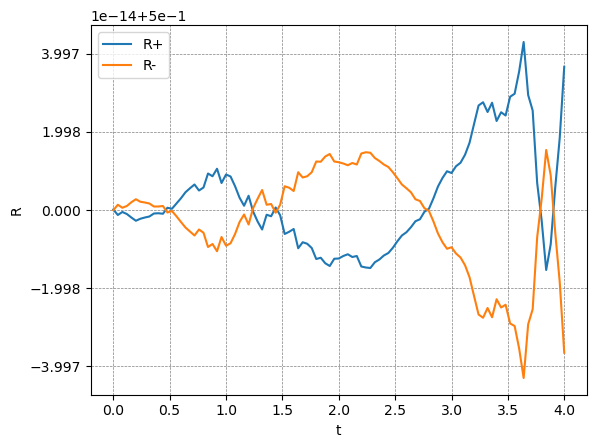

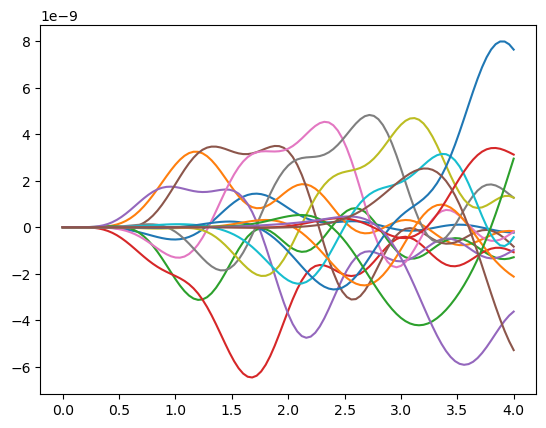

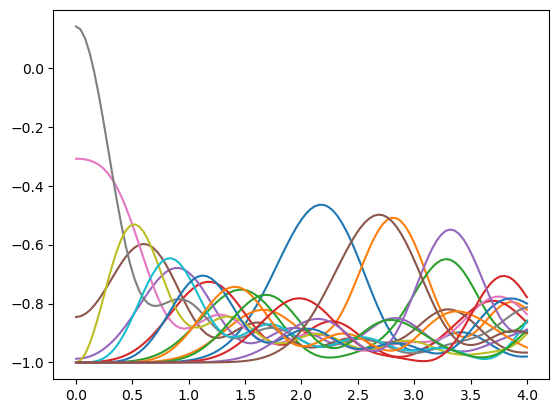

In [ ]:

figure(1)
p3=PyPlot.plot(mytime,Rplus,label="R+")
display(p3)
#figure(2)
p4=PyPlot.plot(mytime,Rminus,label="R-")
PyPlot.grid(true, color="gray", linestyle="--", linewidth=0.5)
PyPlot.xlabel("t")
PyPlot.ylabel("R")
PyPlot.legend()
PyPlot.savefig("$(id)_R.png" )
display(p4)



figure(2)
p3=PyPlot.plot(mytime,mz_array)
display(p3)

figure(3)
p1=PyPlot.plot(mytime,nz_array)
display(p1)


#figure(4)
#p4=PyPlot.plot(mytime,x_array)
#display(p4)



